## Application des estimateurs de grande dimensions sur l'optimisation de portefeuille

### DESCRIPTION

L'idée globalement c'est de challenger les estimateurs et d'analyser leur comportement sur des données réelles. Mon objectif est de backtester le portefeuille minimum variance et d'analyser sa variance, son ratio de Sharp ainsi que son comportement sur la frontiere d'efficience.

<small>

## Feuille de route — Application portefeuille : backtest du portefeuille minimum-variance

</small>

<small>

**Paramètres utilisés**

- Fenêtre train : $n_{\text{train}} = 200$ jours de bourse (201 lignes de prix avant `pct_change`)
- Fenêtre test : $n_{\text{test}} = 200$ jours de bourse (même construction)
- Rendements : **simples** (`pct_change`), pas logarithmiques
- Univers de départ : constituants actuels du S&P 500, historique de prix ajustés (`yfinance`)
- Nettoyage : `dropna(axis=1)` strict sur la fenêtre train+test (aucune tolérance de valeur manquante)
- Univers final : restriction aux 420 premiers tickers propres (`p=420`)
- Grille de p : {40, 52, 67, 88, 114, 148, 192, 249, 323, 420}, soit γ = p/200 ∈ {0.20, ..., 2.10}
- 30 tirages aléatoires stratifiés par secteur GICS, par valeur de p
- Méthodes comparées : Sample, Clipping (Marchenko-Pastur), Linear (Ledoit-Wolf 2004), NLS (Ledoit-Wolf non-linéaire 2020), 1/N (benchmark équipondéré)

</small>

<small>

**Phase 1 — Acquisition et préparation des données**

- Constituants S&P 500 (`sp500_constituents.csv`) avec colonne GICS Sector.
- Téléchargement `yfinance` sur 30 ans, prix ajustés (`auto_adjust=True`), tous les tickers de l'indice.
- Sélection des `N_train + N_test` dernières lignes de prix, puis `dropna(axis=1)` : seuls les tickers sans aucune valeur manquante sur cette fenêtre récente sont conservés.
- Restriction aux 420 premiers tickers propres pour fixer l'univers maximal.
- Calcul des rendements simples (`pct_change`) séparément sur train et test.

</small>

<small>

**Phase 2 — Échantillonnage stratifié des univers par γ**

- Pour chaque p de la grille : proportions sectorielles calculées sur les tickers propres, arrondies puis corrigées pour sommer exactement à p.
- 30 tirages indépendants par p : échantillon aléatoire sans remise par secteur, puis concaténation.
- Sécurité : un secteur ne peut fournir plus de tickers qu'il n'en contient (`clip`).

</small>

<small>

**Phase 3 — Calcul des estimateurs et des portefeuilles GMV (Global Minimum Variance)**

- Pour chaque (p, tirage) : normalisation des rendements train, calcul de la matrice de corrélation empirique et de sa décomposition spectrale.
- 4 estimateurs appliqués sur la corrélation (Sample, Clipping, Linear, NLS), puis reconstruction en covariance via $D\cdot\hat\Sigma_{\text{corr}}\cdot D$ (écarts-types réels).
- Portefeuille GMV par méthode : $w = \hat\Sigma_{\text{cov}}^{-1}\mathbf{1}/(\mathbf{1}^\top\hat\Sigma_{\text{cov}}^{-1}\mathbf{1})$, résolu via `np.linalg.solve`.
- 1/N ajouté comme 5ᵉ méthode (poids égaux ; réutilise la matrice de covariance de Sample pour le calcul de variance).
- Calcul parallélisé sur les 300 combinaisons (p × tirage) via `joblib.Parallel`.

</small>

<small>

**Phase 4 — Métriques in-sample et out-of-sample**

- Pour chaque (p, tirage, méthode) : variance in-sample prédite ($w^\top\hat\Sigma w$), rendement moyen et Sharpe in-sample (rendement réalisé sur train / racine de la variance prédite).
- Même calcul out-of-sample : poids figés (calculés sur train) appliqués aux rendements test, variance et rendement réellement réalisés.
- Écarts (out − in) de variance et de Sharpe stockés pour chaque ligne; signature empirique de l'« error maximization » de Michaud (1989).
- Résultat centralisé dans `df_resultats`.

</small>

<small>

**Phase 5 — Visualisation**

- Courbes de moyenne par méthode, en fonction de γ : variance in-sample, variance out-of-sample, écart de variance, Sharpe in-sample, Sharpe out-of-sample, écart de Sharpe.
- Rang moyen par méthode (1 = meilleur Sharpe réalisé), agrégé sur les 30 tirages, affiché en heatmap p × méthode.
- Taux de victoire par méthode (fraction des tirages où elle obtient le meilleur Sharpe réalisé), même format de heatmap.
- Illustration sur la frontière d'efficience, au ratio de concentration le plus élevé (p=420) : reconstruction de la frontière in-sample pour Clipping/Linear/NLS, avec le point in-sample (sommet, exact par construction) et le point out-of-sample (réalisé) pour chaque méthode, plus 1/N. Une seconde version ajoute Sample via `pinv()` (la matrice étant singulière à ce p), avec un axe recadré pour rester lisible.

</small>

<small>

<!-- **Non encore implémenté dans ce notebook** (prévu dans la feuille de route initiale)

- Test de significativité de Jobson-Korkie (correction de Memmel, 1998) entre méthodes.
- Extension walk-forward glissante avec rebalancement périodique et suivi du turnover. -->

</small>


<small>

## Hypothèses de l'application portefeuille

</small>

<small>

**1. Hypothèses de stationnarité**

- **Stationnarité de $\hat{\bm\Sigma}$** : on suppose que la structure de covariance estimée sur train reste valable sur test : pas de rupture structurelle, pas de changement de régime de marché entre les deux fenêtres. C'est l'hypothèse la plus centrale de toute la démarche : sans elle, comparer performance in-sample et out-of-sample ne mesurerait rien d'interprétable, puisqu'on comparerait deux mondes différents plutôt que la qualité d'un estimateur.
- **Stationnarité de $\hat{\bm\mu}$** : implicitement supposée aussi, bien que le portefeuille GMV (Global Minimum Variance) ne l'utilise pas pour construire les poids. Elle intervient quand même dès qu'on interprète `mean_out` ou le Sharpe réalisé.
- **Observations i.i.d. (indépendantes et identiquement distribuées) dans le temps** : toute la théorie RMT (Random Matrix Theory) sous-jacente suppose que les $n$ observations temporelles sont i.i.d. Or les rendements financiers réels présentent de l'autocorrélation et du regroupement de volatilité.

</small>

<small>

**2. Hypothèses liées à la construction de $\hat{\bm\Sigma}_{\text{cov}}$**

- **Séparabilité corrélation/volatilité** : la reconstruction $D\cdot\hat{\bm\Sigma}_{\text{corr}}\cdot D$ suppose qu'on peut estimer séparément la structure de corrélation et les écarts-types individuels, puis les recombiner sans perte. Ça suppose implicitement que $D$ (les écarts-types réalisés sur train) reste lui aussi représentatif de la période test donc une deuxième couche de l'hypothèse de stationnarité, appliquée cette fois spécifiquement aux volatilités individuelles plutôt qu'à la corrélation.

</small>

<small>

**3. Une hypothèse technique souvent négligée : l'additivité des rendements logarithmiques**

Un rendement de portefeuille est, par définition, une combinaison linéaire des rendements **simples** des actifs : $R_p = \sum_i w_i R_i$. Mais on a travaillé tout du long avec des rendements **logarithmiques**, $r_i = \log(1+R_i)$, et calculé $\bm w^\top \bm r$ comme si c'était le rendement du portefeuille. Or $\log(1+\sum_i w_i R_i) \neq \sum_i w_i \log(1+R_i)$ en général — l'égalité n'est qu'une **approximation au premier ordre**, valable quand les rendements individuels sont petits. C'est une approximation standard et généralement sans grande conséquence à l'échelle quotidienne, mais c'est une hypothèse implicite qu'on n'avait jamais rendue explicite.

</small>

<small>

**4. Biais déjà identifiés**

- Biais de survivance (univers actuel projeté sur 30 ans).
- Nettoyage strict des tickers (`dropna` sans tolérance), qui suppose que l'exclusion n'est pas corrélée avec le phénomène étudié.

</small>

In [1]:
%run setup.py

✅ Projet root ajouté : /home/onyxia/work/Exiom_Internship


#### Phase 7.1 : Acquisition et préparation des données

In [2]:
import itertools
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from joblib import Parallel, delayed

from models.adapted_clipping import *
from models.base import *
from models.data import *
from models.linear_shrinkage import *
from models.non_linear_shrinkage import *
from models.oracle import *
from models.rotation_invariant import *
from models.sample_correlation import *
from models.silverstein_solver import *
from models.simple_clipping import *
from tools.simulation_tools import *
from tools.tools import *

In [3]:
# ============================================================
# PARAMÈTRES
# ============================================================
ANNEES      = 30
N_ACTIONS   = 300
SEED        = 42
SEUIL_NAN   = 0.10
# ============================================================

In [4]:
# import pandas as pd

# constituents = pd.read_csv(
#     "https://raw.githubusercontent.com/datasets/s-and-p-500-companies/main/data/constituents.csv"
# )
# constituents["Symbol"] = constituents["Symbol"].str.replace(".", "-", regex=False)

# print(f"{len(constituents)} entreprises trouvées")
# print(constituents[["Symbol", "Security", "GICS Sector"]].head())

In [5]:
# constituents.to_csv("sp500_constituents.csv", index=False)

In [6]:
current_dir = Path.cwd().parent
file_path = current_dir / "data" / "raw" / "sp500_constituents.csv"

sp500_constituants = pd.read_csv(file_path, sep=',')
sp500_constituants

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927


In [7]:
end_date = '2026-07-01'# datetime.today().strftime("%Y-%m-%d")
start_date = (datetime(2026, 7, 1) - timedelta(days=365 * ANNEES)).strftime("%Y-%m-%d")

tous_les_tickers = sp500_constituants["Symbol"].tolist()

raw = yf.download(
    tous_les_tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=True,
)["Close"]

print(f"Téléchargement terminé : {raw.shape[0]} jours, {raw.shape[1]} tickers")

[*********             19%                       ]  96 of 503 completed$DRI: possibly delisted; no price data found  (1d 1996-07-08 -> 2026-07-01)
[**********            20%                       ]  100 of 503 completed$DD: possibly delisted; no price data found  (1d 1996-07-08 -> 2026-07-01)
[**********            21%                       ]  107 of 503 completed$MRVL: possibly delisted; no price data found  (1d 1996-07-08 -> 2026-07-01)
[***********           22%                       ]  112 of 503 completed$BBY: possibly delisted; no price data found  (1d 1996-07-08 -> 2026-07-01)
[***********           22%                       ]  113 of 503 completed$WDC: possibly delisted; no price data found  (1d 1996-07-08 -> 2026-07-01)
[***********           23%                       ]  117 of 503 completed$EQT: possibly delisted; no price data found  (1d 1996-07-08 -> 2026-07-01)
[************          26%                       ]  130 of 503 completed$IBM: possibly delisted; no price data fo

Téléchargement terminé : 7543 jours, 503 tickers


In [8]:
raw.to_csv("sp500_raw_data.csv", index=True)

In [9]:
sp500_raw_data = pd.read_csv('sp500_raw_data.csv', sep=',', index_col='Date')
sp500_raw_data

,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
1996-07-08,NaN,0.143006,NaN,NaN,4.515359,2.007452,NaN,4.269298,5.695400,6.994166,...,5.671952,NaN,6.556179,8.666021,NaN,NaN,NaN,NaN,7.888889,NaN
1996-07-09,NaN,0.142071,NaN,NaN,4.461766,1.994245,NaN,4.269298,5.609966,7.041743,...,5.740085,NaN,6.599833,8.715262,NaN,NaN,NaN,NaN,7.777778,NaN
1996-07-10,NaN,0.140202,NaN,NaN,4.555555,1.796142,NaN,4.146881,4.727183,7.136906,...,5.791185,NaN,6.651797,8.752190,NaN,NaN,NaN,NaN,7.666667,NaN
1996-07-11,NaN,0.133658,NaN,NaN,4.689225,1.848969,NaN,3.978557,4.470886,7.089327,...,5.859316,NaN,6.634474,8.801429,NaN,NaN,NaN,NaN,7.777778,NaN
1996-07-12,NaN,0.135060,NaN,NaN,4.770074,1.915004,NaN,3.978557,4.499365,6.756272,...,5.791185,NaN,6.651797,8.832206,NaN,NaN,NaN,NaN,7.611111,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-24,131.377304,292.827423,233.229904,144.399994,89.849167,94.919998,127.615517,196.570007,411.905029,74.606483,...,25.069401,103.496628,80.818550,136.019257,111.615234,75.680000,152.252396,90.319992,247.779999,77.628853
2026-06-25,135.249847,274.912903,241.421585,141.880005,92.579689,94.330002,124.325089,193.410004,416.660522,76.057274,...,25.525209,99.137299,81.096313,136.665070,116.556427,74.080002,150.381821,90.959999,243.389999,77.281281
2026-06-26,135.748886,283.535461,251.559433,145.559998,93.453461,97.540001,127.447540,202.729996,385.734772,76.305702,...,25.079309,100.194717,81.572479,135.661560,116.008507,77.820000,155.625397,93.099998,251.529999,75.563248


In [10]:
N_train = 200 + 1
N_test = 200 + 1
p = 420
SEUIL_NAN = 0

sp500_train_test_raw_data = sp500_raw_data.iloc[-(N_train + N_test):,:]
sp500_train_test_raw_data

,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2024-11-19,123.934532,226.635284,157.225220,131.440002,112.854515,95.690002,341.921906,499.609985,204.315887,49.502926,...,28.743567,89.718491,65.304710,112.179855,119.120247,92.419998,127.147057,109.031441,382.399994,170.584625
2024-11-20,126.774323,227.350113,158.348465,135.250000,111.698326,95.709999,344.935883,499.500000,204.879013,49.998055,...,28.734198,89.689003,65.755295,113.777962,119.695229,89.699997,127.859123,107.380486,384.529999,170.691513
2024-11-21,130.215576,226.873566,162.095718,133.259995,112.979782,98.589996,348.780640,504.440002,207.743332,50.158363,...,28.668617,90.200264,67.003746,115.300430,122.170609,92.699997,129.148468,106.525528,392.309998,171.702057
2024-11-22,131.970703,228.213837,167.022888,137.339996,113.461533,99.690002,346.471863,512.150024,208.355026,50.101780,...,29.268221,89.757828,66.975571,115.168045,123.642189,92.260002,130.158813,108.314064,397.190002,171.944962
2024-11-25,132.611618,231.192230,167.126694,140.929993,113.818024,100.059998,349.012482,518.729980,217.083817,49.988621,...,30.195734,91.881569,67.210243,113.446999,125.659531,90.750000,131.871536,109.041267,400.940002,173.645370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-24,131.377304,292.827423,233.229904,144.399994,89.849167,94.919998,127.615517,196.570007,411.905029,74.606483,...,25.069401,103.496628,80.818550,136.019257,111.615234,75.680000,152.252396,90.319992,247.779999,77.628853
2026-06-25,135.249847,274.912903,241.421585,141.880005,92.579689,94.330002,124.325089,193.410004,416.660522,76.057274,...,25.525209,99.137299,81.096313,136.665070,116.556427,74.080002,150.381821,90.959999,243.389999,77.281281
2026-06-26,135.748886,283.535461,251.559433,145.559998,93.453461,97.540001,127.447540,202.729996,385.734772,76.305702,...,25.079309,100.194717,81.572479,135.661560,116.008507,77.820000,155.625397,93.099998,251.529999,75.563248


In [11]:
sp500_train_test_clean_data = sp500_train_test_raw_data.dropna(axis=1)
sp500_train_test_clean_data

,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2024-11-19,123.934532,226.635284,157.225220,131.440002,112.854515,95.690002,341.921906,499.609985,204.315887,49.502926,...,28.743567,89.718491,65.304710,112.179855,119.120247,92.419998,127.147057,109.031441,382.399994,170.584625
2024-11-20,126.774323,227.350113,158.348465,135.250000,111.698326,95.709999,344.935883,499.500000,204.879013,49.998055,...,28.734198,89.689003,65.755295,113.777962,119.695229,89.699997,127.859123,107.380486,384.529999,170.691513
2024-11-21,130.215576,226.873566,162.095718,133.259995,112.979782,98.589996,348.780640,504.440002,207.743332,50.158363,...,28.668617,90.200264,67.003746,115.300430,122.170609,92.699997,129.148468,106.525528,392.309998,171.702057
2024-11-22,131.970703,228.213837,167.022888,137.339996,113.461533,99.690002,346.471863,512.150024,208.355026,50.101780,...,29.268221,89.757828,66.975571,115.168045,123.642189,92.260002,130.158813,108.314064,397.190002,171.944962
2024-11-25,132.611618,231.192230,167.126694,140.929993,113.818024,100.059998,349.012482,518.729980,217.083817,49.988621,...,30.195734,91.881569,67.210243,113.446999,125.659531,90.750000,131.871536,109.041267,400.940002,173.645370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-24,131.377304,292.827423,233.229904,144.399994,89.849167,94.919998,127.615517,196.570007,411.905029,74.606483,...,25.069401,103.496628,80.818550,136.019257,111.615234,75.680000,152.252396,90.319992,247.779999,77.628853
2026-06-25,135.249847,274.912903,241.421585,141.880005,92.579689,94.330002,124.325089,193.410004,416.660522,76.057274,...,25.525209,99.137299,81.096313,136.665070,116.556427,74.080002,150.381821,90.959999,243.389999,77.281281
2026-06-26,135.748886,283.535461,251.559433,145.559998,93.453461,97.540001,127.447540,202.729996,385.734772,76.305702,...,25.079309,100.194717,81.572479,135.661560,116.008507,77.820000,155.625397,93.099998,251.529999,75.563248


In [12]:
prices_train = sp500_train_test_clean_data.iloc[:N_train,:p]
prices_test = sp500_train_test_clean_data.iloc[N_train:N_train + N_test,:p]
prices_train

,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,TEL,TER,TFC,TGT,TJX,TKO,TMO,TMUS,TPL,TPR
Date,,,,,,,,,,,,,,,,,,,,,
2024-11-19,123.934532,226.635284,157.225220,131.440002,112.854515,95.690002,341.921906,499.609985,204.315887,49.502926,...,143.000671,102.120186,43.103386,144.359955,117.009537,127.718491,505.553741,225.169342,468.008820,53.930504
2024-11-20,126.774323,227.350113,158.348465,135.250000,111.698326,95.709999,344.935883,499.500000,204.879013,49.998055,...,143.847305,102.895035,42.687424,113.452324,117.185707,129.572479,509.247650,227.361160,478.083282,53.620224
2024-11-21,130.215576,226.873566,162.095718,133.259995,112.979782,98.589996,348.780640,504.440002,207.743332,50.158363,...,146.474716,104.822197,43.269779,113.331154,117.215050,133.573135,512.484741,228.432938,499.448242,54.696507
2024-11-22,131.970703,228.213837,167.022888,137.339996,113.461533,99.690002,346.471863,512.150024,208.355026,50.101780,...,148.810577,107.494415,44.332798,116.518852,118.878799,132.480270,509.664673,230.074387,570.127563,57.130268
2024-11-25,132.611618,231.192230,167.126694,140.929993,113.818024,100.059998,349.012482,518.729980,217.083817,49.988621,...,149.269928,110.060204,44.462215,121.663902,122.127968,133.475555,510.598083,231.677277,531.899414,59.001637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-04,127.457214,238.897522,206.590958,125.370003,129.809616,92.220001,247.833023,344.309998,243.069931,60.181629,...,206.296829,119.039421,45.136456,89.101944,139.320251,186.408173,487.338409,246.904129,307.751038,104.079720
2025-09-05,127.725060,238.807846,206.164185,123.809998,129.936691,91.290001,249.802444,348.970001,244.018082,61.153236,...,206.494690,119.967628,44.609051,89.544052,137.581451,190.252457,490.434784,247.530899,294.585327,102.855492
2025-09-08,127.110001,237.004501,203.477539,124.620003,129.213409,90.900002,250.409927,358.660004,245.904480,60.531410,...,205.634033,118.670135,44.119995,87.939041,139.142426,196.597473,485.506500,237.874878,302.334351,103.487350


In [13]:
prices_test

,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,TEL,TER,TFC,TGT,TJX,TKO,TMO,TMUS,TPL,TPR
Date,,,,,,,,,,,,,,,,,,,,,
2025-09-11,125.721153,229.183411,213.593719,123.050003,129.653229,92.290001,239.220490,350.549988,245.173599,59.676392,...,210.115311,115.336594,43.439163,87.958260,139.132553,198.333282,489.250000,236.396118,311.083893,105.511292
2025-09-12,122.258926,233.208527,211.770279,122.550003,130.708832,92.260002,233.723755,349.359985,242.181046,59.822132,...,207.563065,112.023010,43.343273,86.458969,137.798813,198.529404,477.352539,236.719284,310.480927,105.116371
2025-09-15,124.629898,235.828857,211.062256,120.370003,128.363037,89.860001,233.067291,347.100006,241.884750,58.811653,...,208.878738,113.849480,42.940521,85.113449,139.468445,201.295502,472.798523,234.780258,305.958679,108.769333
2025-09-16,126.177483,237.273514,209.752869,121.660004,129.760742,87.379997,232.028687,352.730011,241.084763,60.579990,...,210.273590,113.709747,42.729565,86.228310,137.867981,197.161118,479.056549,232.704102,309.984009,108.107857
2025-09-17,125.711220,238.110443,214.165955,123.199997,131.138901,87.349998,236.369263,362.070007,243.277344,59.355759,...,211.529922,114.098984,43.515881,85.469048,138.352066,198.234116,470.984924,234.496246,302.473511,108.483017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-24,131.377304,292.827423,233.229904,144.399994,89.849167,94.919998,127.615517,196.570007,411.905029,74.606483,...,197.777740,427.035980,49.301403,140.124466,164.650497,202.680069,491.823029,179.752548,376.954834,149.184464
2026-06-25,135.249847,274.912903,241.421585,141.880005,92.579689,94.330002,124.325089,193.410004,416.660522,76.057274,...,199.291840,471.778778,50.172764,138.506897,154.701889,202.968903,505.362640,180.528091,390.413239,145.448639
2026-06-26,135.748886,283.535461,251.559433,145.559998,93.453461,97.540001,127.447540,202.729996,385.734772,76.305702,...,196.970901,436.692230,49.994534,139.320648,154.941116,214.999634,512.637085,181.631699,395.155640,145.448639


In [14]:
returns_train = prices_train.pct_change().dropna(axis=0)
returns_test = prices_test.pct_change().dropna(axis=0)
returns_train

,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,TEL,TER,TFC,TGT,TJX,TKO,TMO,TMUS,TPL,TPR
Date,,,,,,,,,,,,,,,,,,,,,
2024-11-20,0.022914,0.003154,0.007144,0.028987,-0.010245,0.000209,0.008815,-0.000220,0.002756,0.010002,...,0.005920,0.007588,-0.009650,-0.214101,0.001506,0.014516,0.007307,0.009734,0.021526,-0.005753
2024-11-21,0.027145,-0.002096,0.023665,-0.014714,0.011472,0.030091,0.011146,0.009890,0.013981,0.003206,...,0.018265,0.018729,0.013642,-0.001068,0.000250,0.030876,0.006357,0.004714,0.044689,0.020072
2024-11-22,0.013479,0.005908,0.030397,0.030617,0.004264,0.011157,-0.006620,0.015284,0.002944,-0.001128,...,0.015947,0.025493,0.024567,0.028127,0.014194,-0.008182,-0.005503,0.007186,0.141515,0.044496
2024-11-25,0.004856,0.013051,0.000622,0.026139,0.003142,0.003711,0.007333,0.012848,0.041894,-0.002259,...,0.003087,0.023869,0.002919,0.044156,0.027332,0.007513,0.001831,0.006967,-0.067052,0.032756
2024-11-26,-0.000892,0.009404,0.023043,-0.008941,-0.001439,0.003498,0.005231,0.012666,-0.020261,0.013394,...,-0.018791,-0.014548,-0.008316,-0.030491,0.011299,0.003582,-0.002373,0.020755,-0.026165,0.003451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-04,0.026034,0.005493,0.005381,0.003763,0.004766,-0.007320,-0.004761,-0.012023,0.006379,0.003564,...,0.012428,-0.002006,0.014221,0.003898,0.011113,0.018595,0.010195,-0.002137,0.021386,0.013310
2025-09-05,0.002101,-0.000375,-0.002066,-0.012443,0.000979,-0.010085,0.007947,0.013534,0.003901,0.016145,...,0.000959,0.007797,-0.011685,0.004962,-0.012481,0.020623,0.006354,0.002539,-0.042780,-0.011762
2025-09-08,-0.004815,-0.007551,-0.013032,0.006542,-0.005566,-0.004272,0.002432,0.027767,0.007731,-0.010168,...,-0.004168,-0.010815,-0.010963,-0.017924,0.011346,0.033351,-0.010049,-0.039009,0.026305,0.006143


In [15]:
returns_test

,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,TEL,TER,TFC,TGT,TJX,TKO,TMO,TMUS,TPL,TPR
Date,,,,,,,,,,,,,,,,,,,,,
2025-09-12,-0.027539,0.017563,-0.008537,-0.004063,0.008142,-0.000325,-0.022978,-0.003395,-0.012206,0.002442,...,-0.012147,-0.028730,-0.002207,-0.017045,-0.009586,0.000989,-0.024318,0.001367,-0.001938,-0.003743
2025-09-15,0.019393,0.011236,-0.003343,-0.017789,-0.017947,-0.026013,-0.002809,-0.006469,-0.001223,-0.016891,...,0.006339,0.016304,-0.009292,-0.015563,0.012116,0.013933,-0.009540,-0.008191,-0.014565,0.034752
2025-09-16,0.012417,0.006126,-0.006204,0.010717,0.010889,-0.027599,-0.004456,0.016220,-0.003307,0.030068,...,0.006678,-0.001227,-0.004913,0.013099,-0.011475,-0.020539,0.013236,-0.008843,0.013156,-0.006081
2025-09-17,-0.003695,0.003527,0.021039,0.012658,0.010621,-0.000343,0.018707,0.026479,0.009095,-0.020209,...,0.005975,0.003423,0.018402,-0.008805,0.003511,0.005442,-0.016849,0.007701,-0.024229,0.003470
2025-09-18,0.007102,-0.004645,0.005344,0.018425,0.002981,0.009617,-0.007006,0.014887,0.011083,-0.004256,...,0.016275,0.039363,0.015425,0.005510,-0.000785,0.007051,0.017899,-0.002589,0.000296,0.031125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-24,0.039157,-0.004145,0.000554,0.039971,-0.000442,0.012912,0.016849,-0.004356,0.014487,-0.010021,...,-0.022162,0.016852,0.002416,0.052867,0.004989,0.003996,0.048684,-0.020480,0.020708,-0.005182
2026-06-25,0.029477,-0.061178,0.035123,-0.017451,0.030390,-0.006216,-0.025784,-0.016076,0.011545,0.019446,...,0.007656,0.104775,0.017674,-0.011544,-0.060423,0.001425,0.027529,0.004315,0.035703,-0.025042
2026-06-26,0.003690,0.031365,0.041992,0.025937,0.009438,0.034029,0.025115,0.048188,-0.074223,0.003266,...,-0.011646,-0.074371,-0.003552,0.005875,0.001546,0.059274,0.014395,0.006113,0.012147,0.000000


In [16]:
train = returns_train
test = returns_test

### Phase 2 : Échantillonnage stratifié des univers par γ

In [17]:
p_grid = [40, 52, 67, 88, 114, 148, 192, 249, 323, 412]
n_draws = 30
rng = np.random.default_rng(seed=42)

# Sous-étape 1 : ne garder que les secteurs des tickers propres
clean_sectors = sp500_constituants[sp500_constituants["Symbol"].isin(train.columns)]
sector_counts = clean_sectors["GICS Sector"].value_counts()
proportions = sector_counts / sector_counts.sum()

tirages = {}

for p in p_grid:
    # Sous-étape 2 : nombre de tickers par secteur, arrondi, résidu corrigé sur le plus grand secteur
    counts_per_sector = (proportions * p).round().astype(int)
    ecart = p - counts_per_sector.sum()
    secteur_principal = counts_per_sector.idxmax()
    counts_per_sector[secteur_principal] += ecart

    # Sécurité : un secteur ne peut pas fournir plus de tickers qu'il n'en contient
    counts_per_sector = counts_per_sector.clip(upper=sector_counts)

    # Sous-étape 3 et 4 : 30 tirages indépendants, un par secteur puis concaténation
    tirages[p] = []
    for _ in range(n_draws):
        selection = []
        for secteur, k in counts_per_sector.items():
            pool = clean_sectors.loc[clean_sectors["GICS Sector"] == secteur, "Symbol"]
            tirage_secteur = pool.sample(n=k, replace=False, random_state=rng)
            selection.extend(tirage_secteur.tolist())
        tirages[p].append(selection)

#### Phase 3 : Calcul des estimateurs et des portefeuilles GMV (Global Minimum Variance)

In [18]:


p_grid = [40, 52, 67, 88, 114, 148, 192, 249, 323, 412]
n_train = 200
n_draws = 30


def run_tirage_p3(p, i):
    tirage = tirages[p][i]
    sub = train[tirage]

    std_vec = sub.std(axis=0).values
    D = np.diag(std_vec)

    data_object = DataClass().fit(sub.values)
    # X_norm = normalisation(sub.values)
    S_corr = SampleCorrelationEstimator().fit(data_object).correlation_

    matrices_corr = {
        "Sample": S_corr,
        "Clipping": NaiveClippingEstimator().fit(data_object).correlation_,
        "Linear": LinearShrinkageEstimator().fit(data_object).correlation_,
        "NLS": NonLinearShrinkageEstimator().fit(data_object).correlation_,
    }

    portefeuilles = {}
    for nom, S_c in matrices_corr.items():
        sigma_cov = D @ S_c @ D
        if nom == "Sample" and p > sub.shape[0]:
            # matrice singuliere (rang <= n < p) : solve() explose numeriquement
            # (meme repli que dans les cellules de visualisation plus bas dans ce notebook)
            w = np.linalg.pinv(sigma_cov, rcond=1e-10) @ np.ones(p)
        else:
            w = np.linalg.solve(sigma_cov, np.ones(p))
        w = w / w.sum()
        portefeuilles[nom] = {"w": w, "sigma_cov": sigma_cov}

    w_equal = np.ones(p) / p
    portefeuilles["1/N"] = {"w": w_equal, "sigma_cov": portefeuilles["Sample"]["sigma_cov"]}

    return p, i, portefeuilles


taches = list(itertools.product(p_grid, range(n_draws)))
print(f"{len(taches)} taches a lancer")

sorties = Parallel(n_jobs=-2, verbose=5)(
    delayed(run_tirage_p3)(p, i) for (p, i) in taches
)

resultats = {p: [None] * n_draws for p in p_grid}
for p, i, portefeuilles in sorties:
    resultats[p][i] = portefeuilles

300 taches a lancer


[Parallel(n_jobs=-2)]: Using backend LokyBackend with 29 concurrent workers.
[Parallel(n_jobs=-2)]: Done  14 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-2)]: Done 104 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-2)]: Done 230 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-2)]: Done 300 out of 300 | elapsed:    5.3s finished


#### Phase 4

In [19]:
lignes = []

for p in p_grid:
    for i in range(n_draws):
        tirage = tirages[p][i]
        sub_train = train[tirage].values
        sub_test = test[tirage].values

        for nom, contenu in resultats[p][i].items():
            w = contenu["w"]
            sigma_cov = contenu["sigma_cov"]

            var_in = w @ sigma_cov @ w
            rendements_in = sub_train @ w
            mean_in = rendements_in.mean()
            sharpe_in = mean_in / np.sqrt(var_in)

            rendements_out = sub_test @ w
            var_out = rendements_out.var(ddof=1)
            mean_out = rendements_out.mean()
            sharpe_out = mean_out / np.sqrt(var_out)

            lignes.append({
                "p": p,
                "tirage": i,
                "methode": nom,
                "var_in": var_in,
                "var_out": var_out,
                "mean_in": mean_in,
                "mean_out": mean_out,
                "sharpe_in": sharpe_in,
                "sharpe_out": sharpe_out,
                "ecart_variance": var_out - var_in,
                "ecart_sharpe": sharpe_out - sharpe_in,
            })

df_resultats = pd.DataFrame(lignes)

In [20]:
df_resultats

,p,tirage,methode,var_in,var_out,mean_in,mean_out,sharpe_in,sharpe_out,ecart_variance,ecart_sharpe
0,40,0,Sample,0.000043,0.000068,0.000698,0.000131,0.106725,0.015937,0.000025,-0.090788
1,40,0,Clipping,0.000044,0.000049,0.000664,-0.000026,0.099572,-0.003683,0.000004,-0.103255
2,40,0,Linear,0.000044,0.000048,0.000598,0.000036,0.090082,0.005176,0.000004,-0.084906
3,40,0,NLS,0.000046,0.000049,0.000643,0.000010,0.095240,0.001458,0.000003,-0.093782
4,40,0,1/N,0.000150,0.000060,0.000550,0.000066,0.044938,0.008453,-0.000090,-0.036485
...,...,...,...,...,...,...,...,...,...,...,...
1495,412,29,Sample,0.000013,0.000103,-0.000113,0.000791,-0.030966,0.077836,0.000090,0.108802
1496,412,29,Clipping,0.000010,0.000063,0.001254,0.000719,0.399485,0.090266,0.000054,-0.309218
1497,412,29,Linear,0.000008,0.000061,0.000304,0.000424,0.106962,0.054160,0.000053,-0.052803
1498,412,29,NLS,0.000012,0.000048,0.000610,0.000409,0.176511,0.058829,0.000036,-0.117683


#### Phase 5 : Visualisation

Variance — in-sample

In [21]:
couleurs = {"Sample": "black", "Clipping": "royalblue", "Linear": "forestgreen", "NLS": "red", "1/N": "purple"}
methodes = list(couleurs.keys())
offsets = np.linspace(-0.3, 0.3, len(methodes))

In [22]:
n_train = 200
gamma_values = [p / n_train for p in p_grid]
positions = np.arange(len(p_grid))

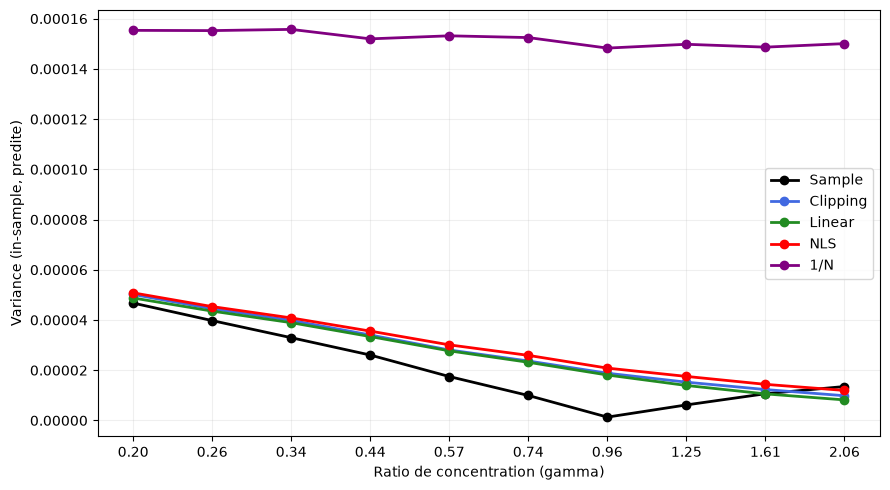

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))

for methode, couleur in couleurs.items():
    moyennes = df_resultats[df_resultats["methode"] == methode].groupby("p")["var_in"].mean()
    ax.plot(positions, moyennes.reindex(p_grid).values, marker="o", linewidth=2, color=couleur, label=methode)

ax.set_xticks(positions)
ax.set_xticklabels([f"{g:.2f}" for g in gamma_values])
ax.set_xlabel("Ratio de concentration (gamma)")
ax.set_ylabel("Variance (in-sample, predite)")
ax.legend()
# ax.set_ylim(0, 0.00006)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Variance — out-of-sample

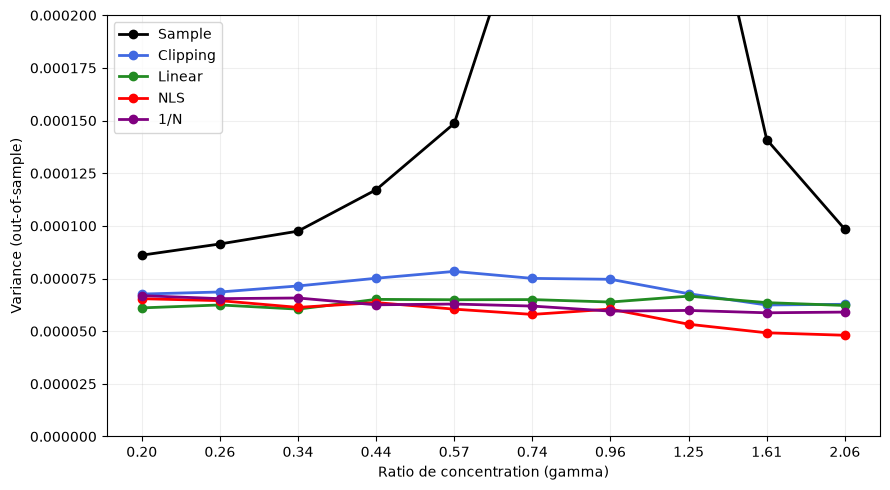

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))

for methode, couleur in couleurs.items():
    moyennes = df_resultats[df_resultats["methode"] == methode].groupby("p")["var_out"].mean()
    ax.plot(positions, moyennes.reindex(p_grid).values, marker="o", linewidth=2, color=couleur, label=methode)

ax.set_xticks(positions)
ax.set_xticklabels([f"{g:.2f}" for g in gamma_values])
ax.set_xlabel("Ratio de concentration (gamma)")
ax.set_ylabel("Variance (out-of-sample)")
ax.legend()
ax.set_ylim(0, 0.0002)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Variance : écart (out − in)

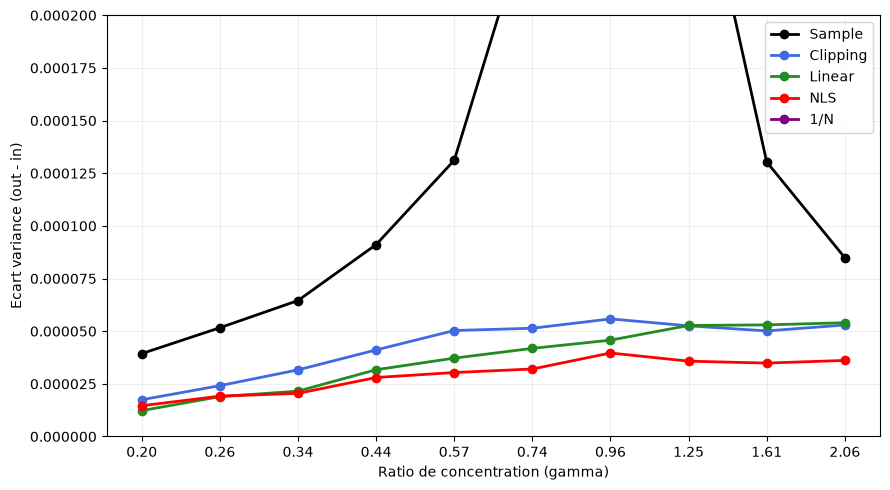

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))

for methode, couleur in couleurs.items():
    moyennes = df_resultats[df_resultats["methode"] == methode].groupby("p")["ecart_variance"].mean()
    ax.plot(positions, moyennes.reindex(p_grid).values, marker="o", linewidth=2, color=couleur, label=methode)

ax.set_xticks(positions)
ax.set_xticklabels([f"{g:.2f}" for g in gamma_values])
ax.set_xlabel("Ratio de concentration (gamma)")
ax.set_ylabel("Ecart variance (out - in)")
ax.legend()
ax.set_ylim(0, 0.0002)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Sharpe — in-sample

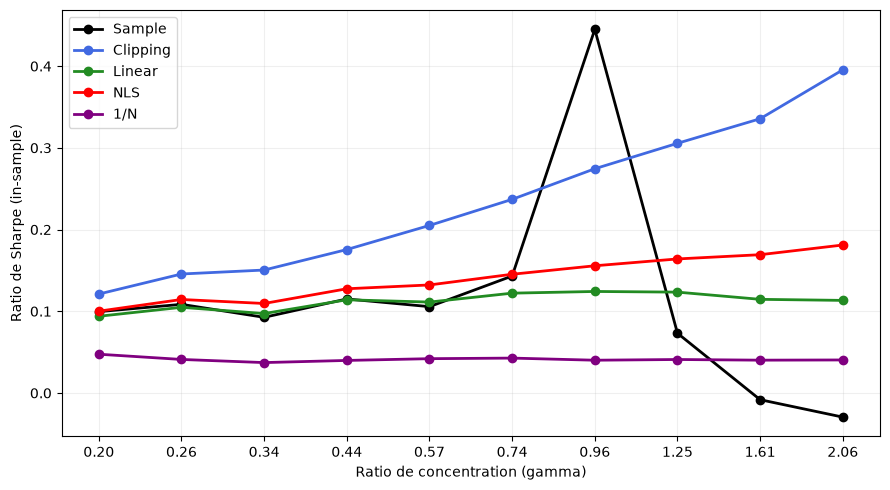

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))

for methode, couleur in couleurs.items():
    moyennes = df_resultats[df_resultats["methode"] == methode].groupby("p")["sharpe_in"].mean()
    ax.plot(positions, moyennes.reindex(p_grid).values, marker="o", linewidth=2, color=couleur, label=methode)

ax.set_xticks(positions)
ax.set_xticklabels([f"{g:.2f}" for g in gamma_values])
ax.set_xlabel("Ratio de concentration (gamma)")
ax.set_ylabel("Ratio de Sharpe (in-sample)")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

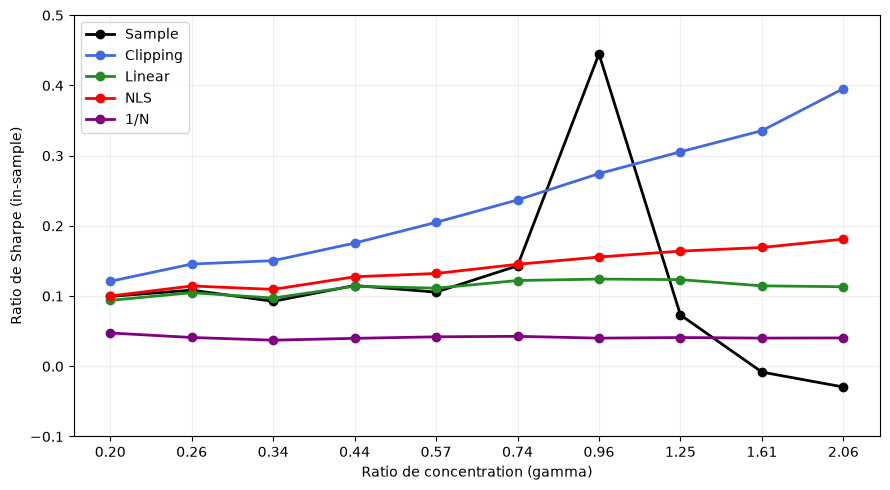

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))

for methode, couleur in couleurs.items():
    moyennes = df_resultats[df_resultats["methode"] == methode].groupby("p")["sharpe_in"].mean()
    ax.plot(positions, moyennes.reindex(p_grid).values, marker="o", linewidth=2, color=couleur, label=methode)

ax.set_xticks(positions)
ax.set_xticklabels([f"{g:.2f}" for g in gamma_values])
ax.set_xlabel("Ratio de concentration (gamma)")
ax.set_ylabel("Ratio de Sharpe (in-sample)")
ax.legend()
ax.set_ylim(-0.1, 0.5)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Sharpe — out-of-sample

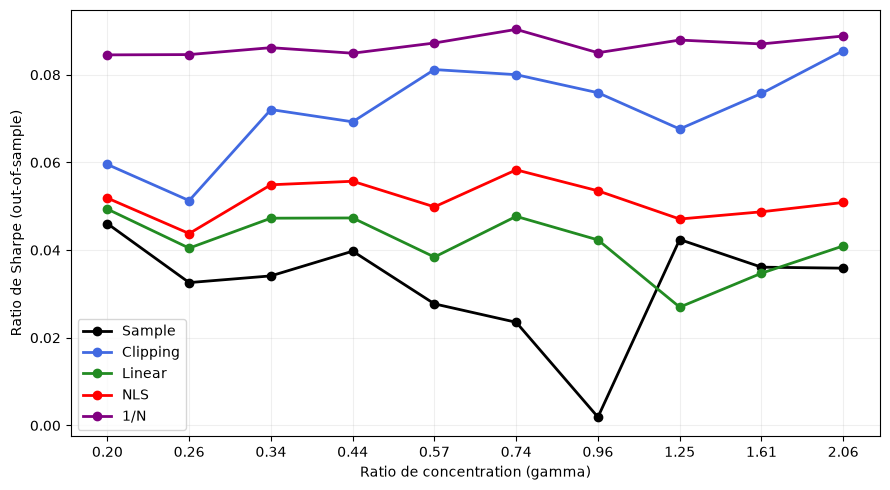

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))

for methode, couleur in couleurs.items():
    moyennes = df_resultats[df_resultats["methode"] == methode].groupby("p")["sharpe_out"].mean()
    ax.plot(positions, moyennes.reindex(p_grid).values, marker="o", linewidth=2, color=couleur, label=methode)

ax.set_xticks(positions)
ax.set_xticklabels([f"{g:.2f}" for g in gamma_values])
ax.set_xlabel("Ratio de concentration (gamma)")
ax.set_ylabel("Ratio de Sharpe (out-of-sample)")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Sharpe — écart (out − in)

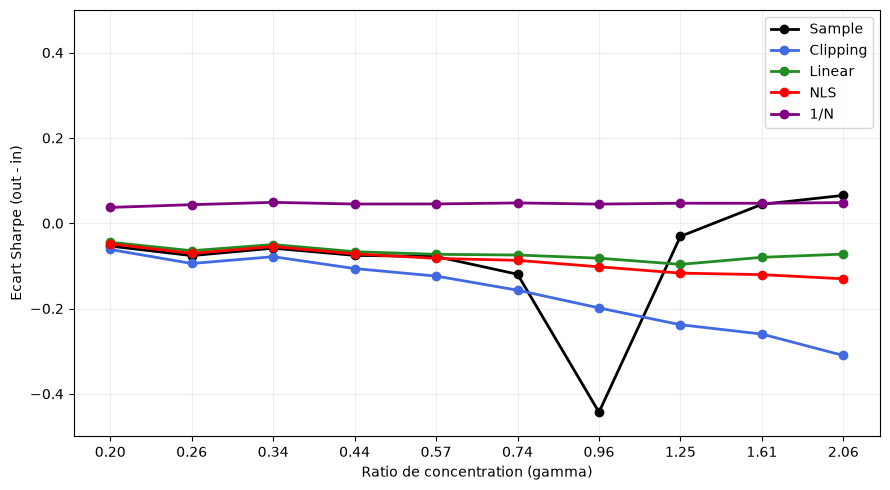

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))

for methode, couleur in couleurs.items():
    moyennes = df_resultats[df_resultats["methode"] == methode].groupby("p")["ecart_sharpe"].mean()
    ax.plot(positions, moyennes.reindex(p_grid).values, marker="o", linewidth=2, color=couleur, label=methode)

ax.set_xticks(positions)
ax.set_xticklabels([f"{g:.2f}" for g in gamma_values])
ax.set_xlabel("Ratio de concentration (gamma)")
ax.set_ylabel("Ecart Sharpe (out - in)")
ax.legend()
ax.set_ylim(-0.5, 0.5)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [30]:
df_resultats["rang"] = df_resultats.groupby(["p", "tirage"])["sharpe_out"].rank(ascending=False, method="first")

rang_moyen = df_resultats.groupby(["p", "methode"])["rang"].mean()
taux_victoire = df_resultats.groupby(["p", "methode"])["rang"].apply(lambda x: (x == 1).mean())

Rang moyen par méthode vs γ

Question : quelle méthode se classe le mieux en moyenne, indépendamment de l'ampleur des écarts (donc insensible à l'explosion de Sample) ? Insight : si Sample a un rang moyen qui se dégrade nettement à mesure que γ augmente (au-delà de simplement "5e systématiquement"), ça confirme le classement qu'on voit déjà sur le Sharpe brut, mais de façon plus robuste statistiquement.

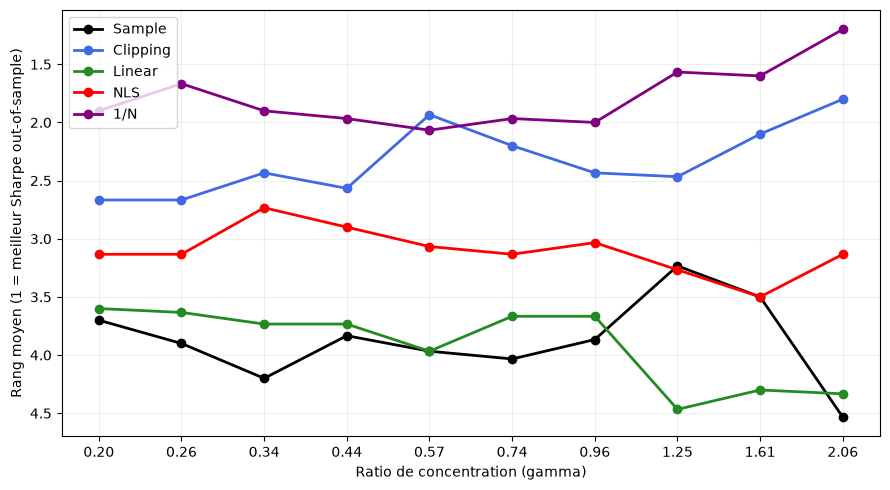

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))

for methode, couleur in couleurs.items():
    valeurs = rang_moyen.xs(methode, level="methode").reindex(p_grid).values
    ax.plot(positions, valeurs, marker="o", linewidth=2, color=couleur, label=methode)

ax.set_xticks(positions)
ax.set_xticklabels([f"{g:.2f}" for g in gamma_values])
ax.set_xlabel("Ratio de concentration (gamma)")
ax.set_ylabel("Rang moyen (1 = meilleur Sharpe out-of-sample)")
ax.invert_yaxis()
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

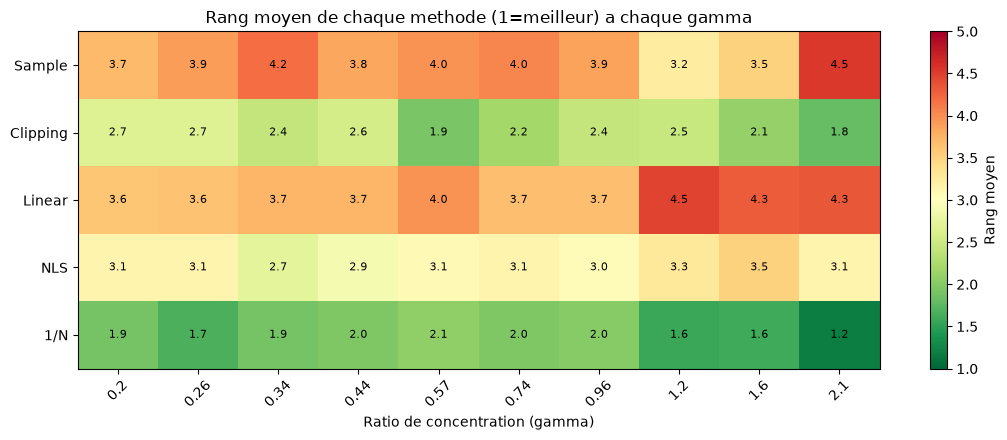

In [32]:
methodes = list(couleurs.keys())
n_methodes = len(methodes)

rang_moyen_matrix = np.array([[rang_moyen.loc[(p, m)] for p in p_grid] for m in methodes])

plt.figure(figsize=(11, 4.5))
im = plt.imshow(rang_moyen_matrix, aspect="auto", cmap="RdYlGn_r", vmin=1, vmax=n_methodes)
plt.yticks(range(n_methodes), methodes)
plt.xticks(range(len(gamma_values)), [f"{g:.2g}" for g in gamma_values], rotation=45)
plt.xlabel("Ratio de concentration (gamma)")
plt.title("Rang moyen de chaque methode (1=meilleur) a chaque gamma")
for i in range(n_methodes):
    for j in range(len(gamma_values)):
        plt.text(j, i, f"{rang_moyen_matrix[i,j]:.1f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, label="Rang moyen")
plt.tight_layout()
plt.show()

Taux de victoire par méthode vs γ

Question : quelle fraction des 30 tirages chaque méthode remporte-t-elle (meilleur Sharpe réalisé) ? Insight : complémentaire au rang moyen, un taux de victoire qui grimpe avec γ pour NLS/Linear confirmerait qu'elles deviennent systématiquement les meilleures, pas juste "en moyenne meilleures à cause de quelques tirages extrêmes".

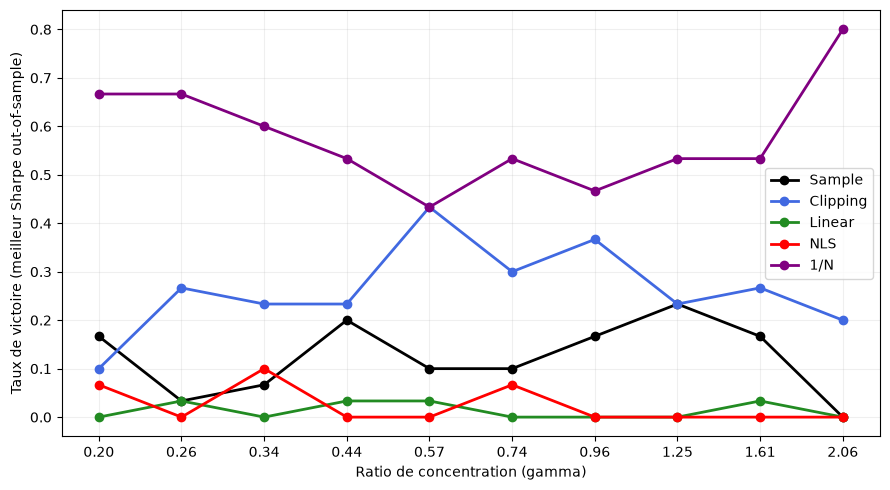

In [33]:
fig, ax = plt.subplots(figsize=(9, 5))

for methode, couleur in couleurs.items():
    valeurs = taux_victoire.xs(methode, level="methode").reindex(p_grid).values
    ax.plot(positions, valeurs, marker="o", linewidth=2, color=couleur, label=methode)

ax.set_xticks(positions)
ax.set_xticklabels([f"{g:.2f}" for g in gamma_values])
ax.set_xlabel("Ratio de concentration (gamma)")
ax.set_ylabel("Taux de victoire (meilleur Sharpe out-of-sample)")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

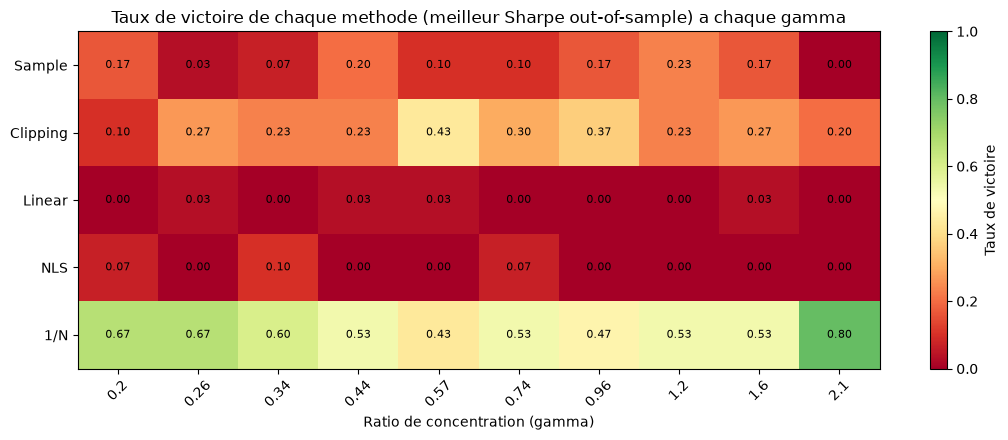

In [34]:
taux_victoire_matrix = np.array([[taux_victoire.loc[(p, m)] for p in p_grid] for m in methodes])

plt.figure(figsize=(11, 4.5))
im = plt.imshow(taux_victoire_matrix, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
plt.yticks(range(n_methodes), methodes)
plt.xticks(range(len(gamma_values)), [f"{g:.2g}" for g in gamma_values], rotation=45)
plt.xlabel("Ratio de concentration (gamma)")
plt.title("Taux de victoire de chaque methode (meilleur Sharpe out-of-sample) a chaque gamma")
for i in range(n_methodes):
    for j in range(len(gamma_values)):
        plt.text(j, i, f"{taux_victoire_matrix[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, label="Taux de victoire")
plt.tight_layout()
plt.show()

#### Frontiere d'efficience

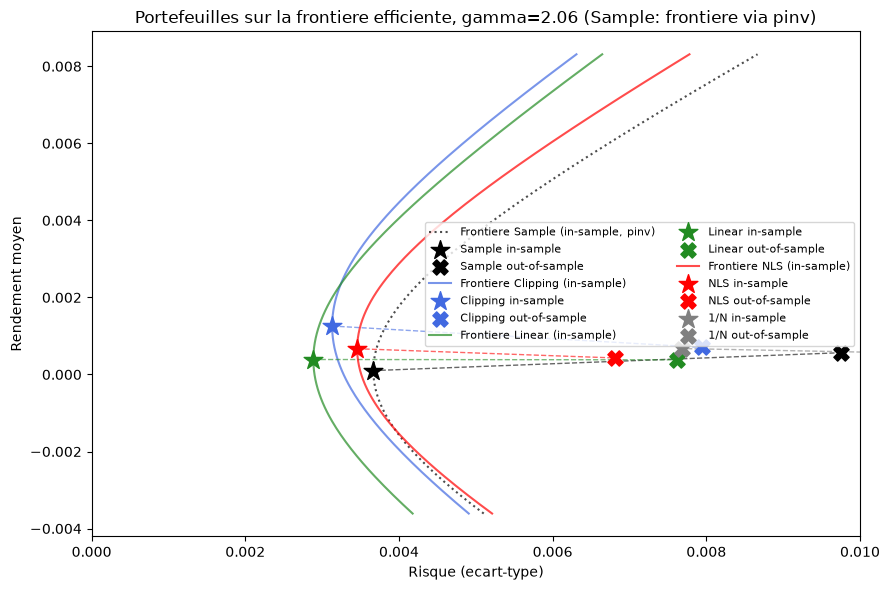

In [40]:
p_max = 412
tirage_max = tirages[p_max][0]
mu_hat = train[tirage_max].mean(axis=0).values

fig, ax = plt.subplots(figsize=(9, 6))

# --- Sample (matrice singuliere a p=420 : pinv() au lieu de solve(), repli numerique pour l'affichage uniquement) ---
sigma_c = resultats[p_max][0]["Sample"]["sigma_cov"]
sigma_pinv = np.linalg.pinv(sigma_c, rcond=1e-10)
x1 = sigma_pinv @ np.ones(p_max)
x2 = sigma_pinv @ mu_hat
A = np.ones(p_max) @ x1
B = np.ones(p_max) @ x2
C = mu_hat @ x2
D = A * C - B**2
mu_grid = np.linspace(mu_hat.min(), mu_hat.max(), 200)
sigma_grid = np.sqrt(np.maximum((A * mu_grid**2 - 2 * B * mu_grid + C) / D, 0))
ax.plot(sigma_grid, mu_grid, color="black", linewidth=1.5, alpha=0.7, linestyle=":", label="Frontiere Sample (in-sample, pinv)")
sigma_in = np.sqrt(df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="Sample")]["var_in"].values[0])
mean_in = df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="Sample")]["mean_in"].values[0]
sigma_out = np.sqrt(df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="Sample")]["var_out"].values[0])
mean_out = df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="Sample")]["mean_out"].values[0]
ax.scatter([sigma_in], [mean_in], color="black", marker="*", s=200, zorder=5, label="Sample in-sample")
ax.scatter([sigma_out], [mean_out], color="black", marker="X", s=120, zorder=5, label="Sample out-of-sample")
ax.plot([sigma_in, sigma_out], [mean_in, mean_out], color="black", linestyle="--", linewidth=1, alpha=0.6)

# --- Clipping ---
sigma_c = resultats[p_max][0]["Clipping"]["sigma_cov"]
x1 = np.linalg.solve(sigma_c, np.ones(p_max))
x2 = np.linalg.solve(sigma_c, mu_hat)
A = np.ones(p_max) @ x1
B = np.ones(p_max) @ x2
C = mu_hat @ x2
D = A * C - B**2
sigma_grid = np.sqrt(np.maximum((A * mu_grid**2 - 2 * B * mu_grid + C) / D, 0))
ax.plot(sigma_grid, mu_grid, color="royalblue", linewidth=1.5, alpha=0.7, label="Frontiere Clipping (in-sample)")
sigma_in = np.sqrt(df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="Clipping")]["var_in"].values[0])
mean_in = df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="Clipping")]["mean_in"].values[0]
sigma_out = np.sqrt(df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="Clipping")]["var_out"].values[0])
mean_out = df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="Clipping")]["mean_out"].values[0]
ax.scatter([sigma_in], [mean_in], color="royalblue", marker="*", s=200, zorder=5, label="Clipping in-sample")
ax.scatter([sigma_out], [mean_out], color="royalblue", marker="X", s=120, zorder=5, label="Clipping out-of-sample")
ax.plot([sigma_in, sigma_out], [mean_in, mean_out], color="royalblue", linestyle="--", linewidth=1, alpha=0.6)

# --- Linear ---
sigma_c = resultats[p_max][0]["Linear"]["sigma_cov"]
x1 = np.linalg.solve(sigma_c, np.ones(p_max))
x2 = np.linalg.solve(sigma_c, mu_hat)
A = np.ones(p_max) @ x1
B = np.ones(p_max) @ x2
C = mu_hat @ x2
D = A * C - B**2
sigma_grid = np.sqrt(np.maximum((A * mu_grid**2 - 2 * B * mu_grid + C) / D, 0))
ax.plot(sigma_grid, mu_grid, color="forestgreen", linewidth=1.5, alpha=0.7, label="Frontiere Linear (in-sample)")
sigma_in = np.sqrt(df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="Linear")]["var_in"].values[0])
mean_in = df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="Linear")]["mean_in"].values[0]
sigma_out = np.sqrt(df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="Linear")]["var_out"].values[0])
mean_out = df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="Linear")]["mean_out"].values[0]
ax.scatter([sigma_in], [mean_in], color="forestgreen", marker="*", s=200, zorder=5, label="Linear in-sample")
ax.scatter([sigma_out], [mean_out], color="forestgreen", marker="X", s=120, zorder=5, label="Linear out-of-sample")
ax.plot([sigma_in, sigma_out], [mean_in, mean_out], color="forestgreen", linestyle="--", linewidth=1, alpha=0.6)

# --- NLS ---
sigma_c = resultats[p_max][0]["NLS"]["sigma_cov"]
x1 = np.linalg.solve(sigma_c, np.ones(p_max))
x2 = np.linalg.solve(sigma_c, mu_hat)
A = np.ones(p_max) @ x1
B = np.ones(p_max) @ x2
C = mu_hat @ x2
D = A * C - B**2
sigma_grid = np.sqrt(np.maximum((A * mu_grid**2 - 2 * B * mu_grid + C) / D, 0))
ax.plot(sigma_grid, mu_grid, color="red", linewidth=1.5, alpha=0.7, label="Frontiere NLS (in-sample)")
sigma_in = np.sqrt(df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="NLS")]["var_in"].values[0])
mean_in = df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="NLS")]["mean_in"].values[0]
sigma_out = np.sqrt(df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="NLS")]["var_out"].values[0])
mean_out = df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="NLS")]["mean_out"].values[0]
ax.scatter([sigma_in], [mean_in], color="red", marker="*", s=200, zorder=5, label="NLS in-sample")
ax.scatter([sigma_out], [mean_out], color="red", marker="X", s=120, zorder=5, label="NLS out-of-sample")
ax.plot([sigma_in, sigma_out], [mean_in, mean_out], color="red", linestyle="--", linewidth=1, alpha=0.6)

# --- 1/N (pas de frontiere, juste les deux points) ---
sigma_in = np.sqrt(df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="1/N")]["var_in"].values[0])
mean_in = df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="1/N")]["mean_in"].values[0]
sigma_out = np.sqrt(df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="1/N")]["var_out"].values[0])
mean_out = df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="1/N")]["mean_out"].values[0]
ax.scatter([sigma_in], [mean_in], color="gray", marker="*", s=200, zorder=5, label="1/N in-sample")
ax.scatter([sigma_out], [mean_out], color="gray", marker="X", s=120, zorder=5, label="1/N out-of-sample")
ax.plot([sigma_in, sigma_out], [mean_in, mean_out], color="gray", linestyle="--", linewidth=1, alpha=0.6)

ax.set_xlabel("Risque (ecart-type)")
ax.set_xlim(0, 0.01)
ax.set_ylabel("Rendement moyen")
ax.set_title(f"Portefeuilles sur la frontiere efficiente, gamma={p_max/200:.2f} (Sample: frontiere via pinv)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

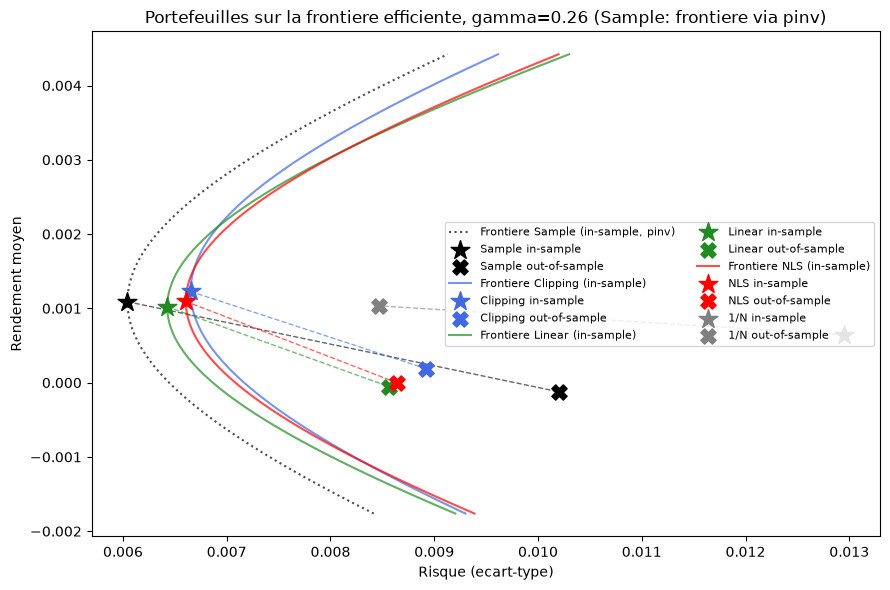

In [41]:
p_max = 52
tirage_max = tirages[p_max][0]
mu_hat = train[tirage_max].mean(axis=0).values

fig, ax = plt.subplots(figsize=(9, 6))

# --- Sample (matrice singuliere a p=420 : pinv() au lieu de solve(), repli numerique pour l'affichage uniquement) ---
sigma_c = resultats[p_max][0]["Sample"]["sigma_cov"]
sigma_pinv = np.linalg.pinv(sigma_c, rcond=1e-10)
x1 = sigma_pinv @ np.ones(p_max)
x2 = sigma_pinv @ mu_hat
A = np.ones(p_max) @ x1
B = np.ones(p_max) @ x2
C = mu_hat @ x2
D = A * C - B**2
mu_grid = np.linspace(mu_hat.min(), mu_hat.max(), 200)
sigma_grid = np.sqrt(np.maximum((A * mu_grid**2 - 2 * B * mu_grid + C) / D, 0))
ax.plot(sigma_grid, mu_grid, color="black", linewidth=1.5, alpha=0.7, linestyle=":", label="Frontiere Sample (in-sample, pinv)")
sigma_in = np.sqrt(df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="Sample")]["var_in"].values[0])
mean_in = df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="Sample")]["mean_in"].values[0]
sigma_out = np.sqrt(df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="Sample")]["var_out"].values[0])
mean_out = df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="Sample")]["mean_out"].values[0]
ax.scatter([sigma_in], [mean_in], color="black", marker="*", s=200, zorder=5, label="Sample in-sample")
ax.scatter([sigma_out], [mean_out], color="black", marker="X", s=120, zorder=5, label="Sample out-of-sample")
ax.plot([sigma_in, sigma_out], [mean_in, mean_out], color="black", linestyle="--", linewidth=1, alpha=0.6)

# --- Clipping ---
sigma_c = resultats[p_max][0]["Clipping"]["sigma_cov"]
x1 = np.linalg.solve(sigma_c, np.ones(p_max))
x2 = np.linalg.solve(sigma_c, mu_hat)
A = np.ones(p_max) @ x1
B = np.ones(p_max) @ x2
C = mu_hat @ x2
D = A * C - B**2
sigma_grid = np.sqrt(np.maximum((A * mu_grid**2 - 2 * B * mu_grid + C) / D, 0))
ax.plot(sigma_grid, mu_grid, color="royalblue", linewidth=1.5, alpha=0.7, label="Frontiere Clipping (in-sample)")
sigma_in = np.sqrt(df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="Clipping")]["var_in"].values[0])
mean_in = df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="Clipping")]["mean_in"].values[0]
sigma_out = np.sqrt(df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="Clipping")]["var_out"].values[0])
mean_out = df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="Clipping")]["mean_out"].values[0]
ax.scatter([sigma_in], [mean_in], color="royalblue", marker="*", s=200, zorder=5, label="Clipping in-sample")
ax.scatter([sigma_out], [mean_out], color="royalblue", marker="X", s=120, zorder=5, label="Clipping out-of-sample")
ax.plot([sigma_in, sigma_out], [mean_in, mean_out], color="royalblue", linestyle="--", linewidth=1, alpha=0.6)

# --- Linear ---
sigma_c = resultats[p_max][0]["Linear"]["sigma_cov"]
x1 = np.linalg.solve(sigma_c, np.ones(p_max))
x2 = np.linalg.solve(sigma_c, mu_hat)
A = np.ones(p_max) @ x1
B = np.ones(p_max) @ x2
C = mu_hat @ x2
D = A * C - B**2
sigma_grid = np.sqrt(np.maximum((A * mu_grid**2 - 2 * B * mu_grid + C) / D, 0))
ax.plot(sigma_grid, mu_grid, color="forestgreen", linewidth=1.5, alpha=0.7, label="Frontiere Linear (in-sample)")
sigma_in = np.sqrt(df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="Linear")]["var_in"].values[0])
mean_in = df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="Linear")]["mean_in"].values[0]
sigma_out = np.sqrt(df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="Linear")]["var_out"].values[0])
mean_out = df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="Linear")]["mean_out"].values[0]
ax.scatter([sigma_in], [mean_in], color="forestgreen", marker="*", s=200, zorder=5, label="Linear in-sample")
ax.scatter([sigma_out], [mean_out], color="forestgreen", marker="X", s=120, zorder=5, label="Linear out-of-sample")
ax.plot([sigma_in, sigma_out], [mean_in, mean_out], color="forestgreen", linestyle="--", linewidth=1, alpha=0.6)

# --- NLS ---
sigma_c = resultats[p_max][0]["NLS"]["sigma_cov"]
x1 = np.linalg.solve(sigma_c, np.ones(p_max))
x2 = np.linalg.solve(sigma_c, mu_hat)
A = np.ones(p_max) @ x1
B = np.ones(p_max) @ x2
C = mu_hat @ x2
D = A * C - B**2
sigma_grid = np.sqrt(np.maximum((A * mu_grid**2 - 2 * B * mu_grid + C) / D, 0))
ax.plot(sigma_grid, mu_grid, color="red", linewidth=1.5, alpha=0.7, label="Frontiere NLS (in-sample)")
sigma_in = np.sqrt(df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="NLS")]["var_in"].values[0])
mean_in = df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="NLS")]["mean_in"].values[0]
sigma_out = np.sqrt(df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="NLS")]["var_out"].values[0])
mean_out = df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="NLS")]["mean_out"].values[0]
ax.scatter([sigma_in], [mean_in], color="red", marker="*", s=200, zorder=5, label="NLS in-sample")
ax.scatter([sigma_out], [mean_out], color="red", marker="X", s=120, zorder=5, label="NLS out-of-sample")
ax.plot([sigma_in, sigma_out], [mean_in, mean_out], color="red", linestyle="--", linewidth=1, alpha=0.6)

# --- 1/N (pas de frontiere, juste les deux points) ---
sigma_in = np.sqrt(df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="1/N")]["var_in"].values[0])
mean_in = df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="1/N")]["mean_in"].values[0]
sigma_out = np.sqrt(df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="1/N")]["var_out"].values[0])
mean_out = df_resultats[(df_resultats["p"]==p_max) & (df_resultats["tirage"]==0) & (df_resultats["methode"]=="1/N")]["mean_out"].values[0]
ax.scatter([sigma_in], [mean_in], color="gray", marker="*", s=200, zorder=5, label="1/N in-sample")
ax.scatter([sigma_out], [mean_out], color="gray", marker="X", s=120, zorder=5, label="1/N out-of-sample")
ax.plot([sigma_in, sigma_out], [mean_in, mean_out], color="gray", linestyle="--", linewidth=1, alpha=0.6)

ax.set_xlabel("Risque (ecart-type)")
# ax.set_xlim(0, 0.01)
ax.set_ylabel("Rendement moyen")
ax.set_title(f"Portefeuilles sur la frontiere efficiente, gamma={p_max/200:.2f} (Sample: frontiere via pinv)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()